In [1]:
"""
Monte Carlo Portfolio Risk Analysis
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import torch
from datetime import datetime, timedelta
from scipy import stats
import time

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [6]:
"""
Download historical stock data for portfolio
Using tech stocks: NVDA, AAPL, MSFT, TSLA, GOOGL
"""

# Define portfolio
tickers = ['NVDA', 'AAPL', 'MSFT', 'TSLA', 'GOOGL']
days_back = 1000
end_date = datetime.now()
start_date = end_date - timedelta(days=days_back)

# Download data for each ticker individually
stock_data = pd.DataFrame()

for ticker in tickers:
    data = yf.download(ticker, start=start_date, end=end_date, progress=False, auto_adjust=True)
    stock_data[ticker] = data[('Close', ticker)]

# Calculate daily returns
returns = stock_data.pct_change().dropna()

# Portfolio weights (equal weighted)
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

# Calculate portfolio statistics
mean_returns = returns.mean()
cov_matrix = returns.cov()
portfolio_return = np.sum(mean_returns * weights) * 252  # Annualized
portfolio_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix * 252, weights)))  # Annualized

# Display portfolio info
portfolio_df = pd.DataFrame({
    'Ticker': tickers,
    'Weight': weights,
    'Avg Daily Return': mean_returns.values,
    'Annual Return': (mean_returns * 252).values,
    'Volatility': (returns.std() * np.sqrt(252)).values
})

print(portfolio_df.to_string(index=False))
print(f"\nPortfolio Metrics:")
print(f"  Expected Annual Return: {portfolio_return*100:.2f}%")
print(f"  Annual Volatility: {portfolio_std*100:.2f}%")
print(f"  Sharpe Ratio (assuming 4% risk-free): {(portfolio_return - 0.04) / portfolio_std:.2f}")
print(f"\nHistorical data: {len(returns)} trading days")

Ticker  Weight  Avg Daily Return  Annual Return  Volatility
  NVDA     0.2          0.003794       0.956174    0.508306
  AAPL     0.2          0.001001       0.252334    0.261917
  MSFT     0.2          0.001230       0.309936    0.231763
  TSLA     0.2          0.002355       0.593365    0.609529
 GOOGL     0.2          0.001547       0.389823    0.301635

Portfolio Metrics:
  Expected Annual Return: 50.03%
  Annual Volatility: 28.40%
  Sharpe Ratio (assuming 4% risk-free): 1.62

Historical data: 687 trading days


In [4]:
"""
GPU-Accelerated Monte Carlo Portfolio Simulation
Simulate thousands of possible portfolio outcomes
"""

def monte_carlo_gpu(mean_returns, cov_matrix, weights, initial_investment, days, num_simulations):
    """
    GPU-accelerated Monte Carlo simulation using PyTorch
    """
    mean_tensor = torch.tensor(mean_returns.values, dtype=torch.float32, device=device)
    cov_tensor = torch.tensor(cov_matrix.values, dtype=torch.float32, device=device)
    weights_tensor = torch.tensor(weights, dtype=torch.float32, device=device)
    
    L = torch.linalg.cholesky(cov_tensor)
    results = torch.zeros(num_simulations, days, device=device)
    z = torch.randn(num_simulations, days, len(weights), device=device)
    
    for sim in range(num_simulations):
        daily_returns = mean_tensor + torch.matmul(z[sim], L.T)
        portfolio_returns = torch.matmul(daily_returns, weights_tensor)
        portfolio_value = initial_investment * torch.cumprod(1 + portfolio_returns, dim=0)
        results[sim] = portfolio_value
    
    return results.cpu().numpy()

# Simulation parameters
initial_investment = 10000
days_forward = 1250
num_simulations = 10000

# Run simulation
start_time = time.time()
simulation_results = monte_carlo_gpu(mean_returns, cov_matrix, weights, initial_investment, days_forward, num_simulations)
elapsed_time = time.time() - start_time

# Calculate key statistics
final_values = simulation_results[:, -1]
percentile_5 = np.percentile(final_values, 5)
percentile_50 = np.percentile(final_values, 50)
percentile_95 = np.percentile(final_values, 95)
mean_final = np.mean(final_values)

# Calculate VaR and CVaR
var_95 = initial_investment - percentile_5
worst_5_percent = final_values[final_values <= percentile_5]
cvar_95 = initial_investment - np.mean(worst_5_percent)


print(f"\nPortfolio Value After 1 Year:")
print(f"  5th Percentile: ${percentile_5:,.2f}")
print(f"  Median (50th): ${percentile_50:,.2f}")
print(f"  Mean: ${mean_final:,.2f}")
print(f"  95th Percentile: ${percentile_95:,.2f}")
print(f"\nRisk Metrics:")
print(f"  VaR (95% confidence): ${var_95:,.2f} ({(var_95/initial_investment)*100:.1f}%)")
print(f"  CVaR: ${cvar_95:,.2f} ({(cvar_95/initial_investment)*100:.1f}%)")



Portfolio Value After 1 Year:
  5th Percentile: $34,466.33
  Median (50th): $98,730.00
  Mean: $120,117.94
  95th Percentile: $276,585.00

Risk Metrics:
  VaR (95% confidence): $-24,466.33 (-244.7%)
  CVaR: $-17,216.53 (-172.2%)


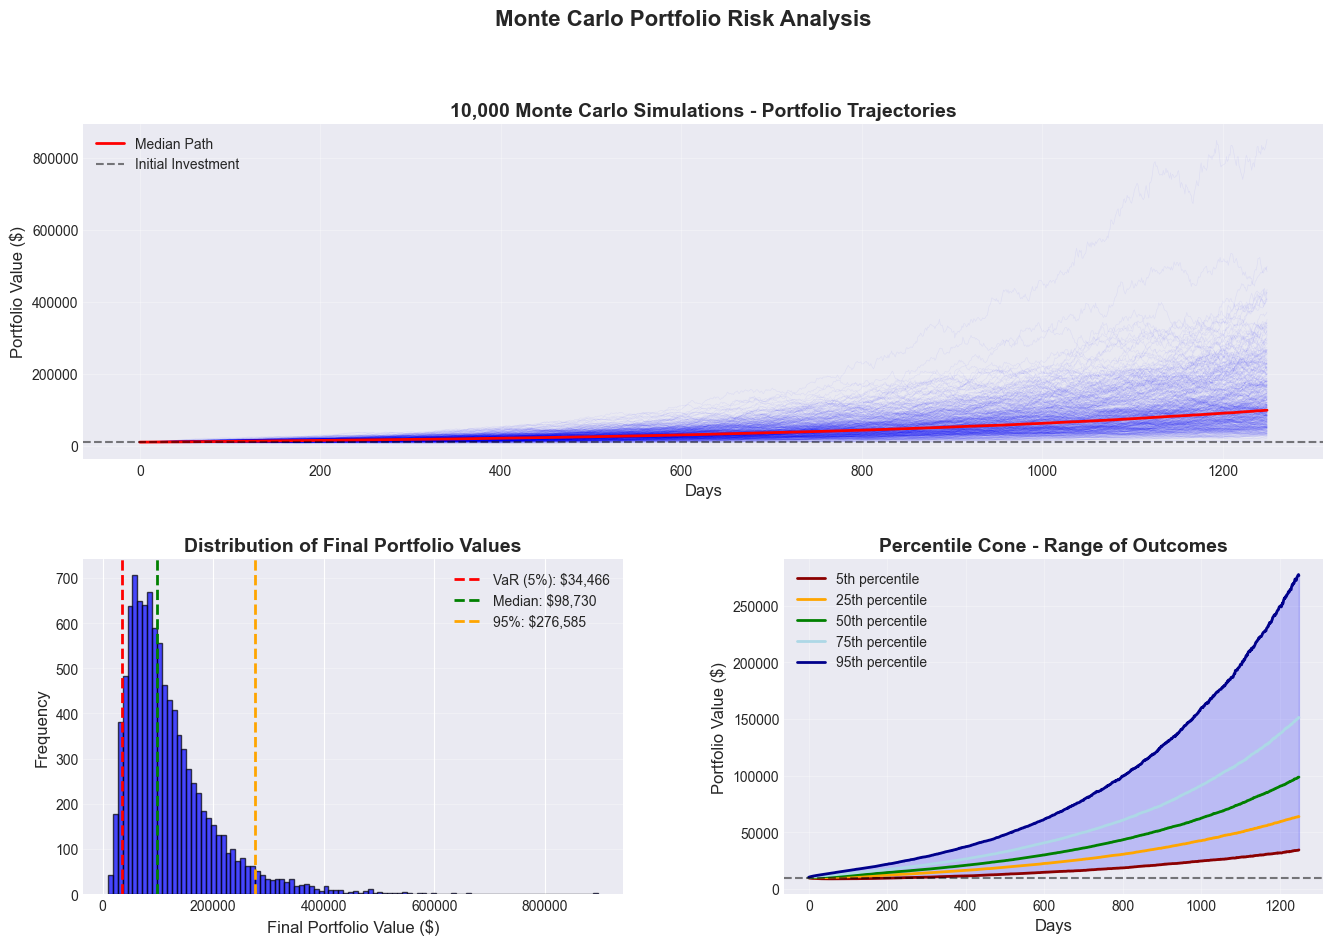

In [5]:
"""
Graph results
"""

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# 1. All simulation paths
ax1 = fig.add_subplot(gs[0, :])
for i in range(min(500, num_simulations)):
    ax1.plot(simulation_results[i], alpha=0.05, color='blue', linewidth=0.5)
ax1.plot(np.median(simulation_results, axis=0), color='red', linewidth=2, label='Median Path')
ax1.axhline(y=initial_investment, color='black', linestyle='--', alpha=0.5, label='Initial Investment')
ax1.set_xlabel('Days', fontsize=12)
ax1.set_ylabel('Portfolio Value ($)', fontsize=12)
ax1.set_title(f'{num_simulations:,} Monte Carlo Simulations - Portfolio Trajectories', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Distribution of final values
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(final_values, bins=100, alpha=0.7, color='blue', edgecolor='black')
ax2.axvline(percentile_5, color='red', linestyle='--', linewidth=2, label=f'VaR (5%): ${percentile_5:,.0f}')
ax2.axvline(percentile_50, color='green', linestyle='--', linewidth=2, label=f'Median: ${percentile_50:,.0f}')
ax2.axvline(percentile_95, color='orange', linestyle='--', linewidth=2, label=f'95%: ${percentile_95:,.0f}')
ax2.set_xlabel('Final Portfolio Value ($)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of Final Portfolio Values', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. Percentile cone
ax3 = fig.add_subplot(gs[1, 1])
percentiles = [5, 25, 50, 75, 95]
percentile_values = np.percentile(simulation_results, percentiles, axis=0)
colors = ['darkred', 'orange', 'green', 'lightblue', 'darkblue']
for i, p in enumerate(percentiles):
    ax3.plot(percentile_values[i], label=f'{p}th percentile', linewidth=2, color=colors[i])
ax3.axhline(y=initial_investment, color='black', linestyle='--', alpha=0.5)
ax3.fill_between(range(days_forward), percentile_values[0], percentile_values[-1], alpha=0.2, color='blue')
ax3.set_xlabel('Days', fontsize=12)
ax3.set_ylabel('Portfolio Value ($)', fontsize=12)
ax3.set_title('Percentile Cone - Range of Outcomes', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.suptitle('Monte Carlo Portfolio Risk Analysis', fontsize=16, fontweight='bold', y=0.995)

plt.show()

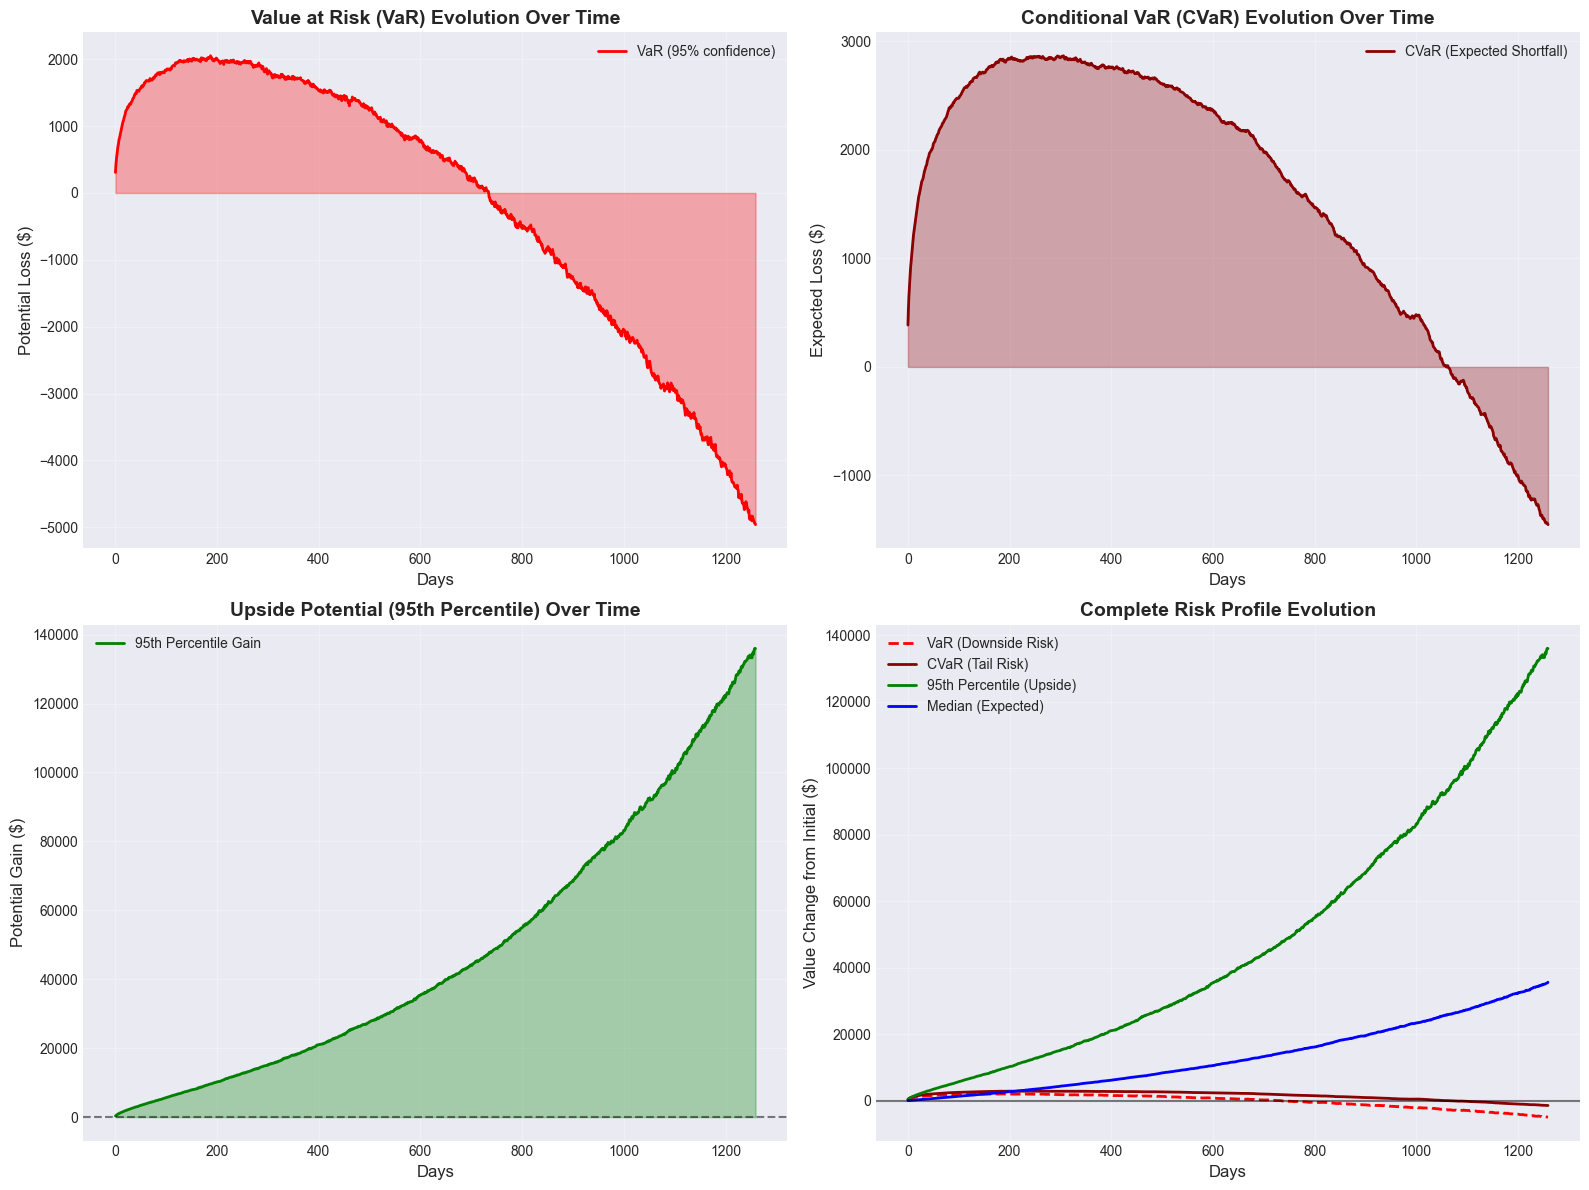

In [ ]:
"""
Calculate VaR, CVaR, and 95th percentile over time
"""

# Calculate metrics for each day
var_over_time = []
cvar_over_time = []
percentile_95_over_time = []
median_over_time = []

for day in range(days_forward):
    # Get portfolio values at this day across all simulations
    values_at_day = simulation_results[:, day]
    
    # Calculate percentiles
    percentile_5 = np.percentile(values_at_day, 5)
    percentile_50 = np.percentile(values_at_day, 50)
    percentile_95 = np.percentile(values_at_day, 95)
    
    # Calculate VaR (loss from initial investment)
    var = initial_investment - percentile_5
    
    # Calculate CVaR (average of worst 5%)
    worst_5_percent = values_at_day[values_at_day <= percentile_5]
    cvar = initial_investment - np.mean(worst_5_percent)
    
    var_over_time.append(var)
    cvar_over_time.append(cvar)
    percentile_95_over_time.append(percentile_95)
    median_over_time.append(percentile_50)

# Convert to arrays
var_over_time = np.array(var_over_time)
cvar_over_time = np.array(cvar_over_time)
percentile_95_over_time = np.array(percentile_95_over_time)
median_over_time = np.array(median_over_time)

# Visualize evolution of risk metrics
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. VaR over time
ax1.plot(var_over_time, linewidth=2, color='red', label='VaR (95% confidence)')
ax1.fill_between(range(days_forward), 0, var_over_time, alpha=0.3, color='red')
ax1.set_xlabel('Days', fontsize=12)
ax1.set_ylabel('Potential Loss ($)', fontsize=12)
ax1.set_title('Value at Risk (VaR) Evolution Over Time', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# 2. CVaR over time
ax2.plot(cvar_over_time, linewidth=2, color='darkred', label='CVaR (Expected Shortfall)')
ax2.fill_between(range(days_forward), 0, cvar_over_time, alpha=0.3, color='darkred')
ax2.set_xlabel('Days', fontsize=12)
ax2.set_ylabel('Expected Loss ($)', fontsize=12)
ax2.set_title('Conditional VaR (CVaR) Evolution Over Time', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

# 3. 95th percentile over time
gains_95 = percentile_95_over_time - initial_investment
ax3.plot(gains_95, linewidth=2, color='green', label='95th Percentile Gain')
ax3.fill_between(range(days_forward), 0, gains_95, alpha=0.3, color='green')
ax3.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax3.set_xlabel('Days', fontsize=12)
ax3.set_ylabel('Potential Gain ($)', fontsize=12)
ax3.set_title('Upside Potential (95th Percentile) Over Time', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend()

# 4. All risk metrics together
ax4.plot(var_over_time, linewidth=2, color='red', label='VaR (Downside Risk)', linestyle='--')
ax4.plot(cvar_over_time, linewidth=2, color='darkred', label='CVaR (Tail Risk)')
ax4.plot(gains_95, linewidth=2, color='green', label='95th Percentile (Upside)')
ax4.plot(median_over_time - initial_investment, linewidth=2, color='blue', label='Median (Expected)')
ax4.axhline(y=0, color='black', linestyle='-', alpha=0.5)
ax4.set_xlabel('Days', fontsize=12)
ax4.set_ylabel('Value Change from Initial ($)', fontsize=12)
ax4.set_title('Complete Risk Profile Evolution', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()